In [18]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

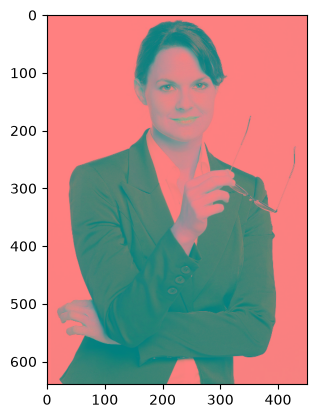

In [19]:
def path_to_lab(image_path : str , WIDTH = None, HEIGHT = None):
    
    img_bgr = cv2.imread(image_path)

    # Raise if iamge not found
    if img_bgr is None:
        raise ValueError( "No image found in said path" )

    # Raise if only height or width is given
    if WIDTH is None and HEIGHT is not None:
        raise ValueError( "Give bot width and height to crop image" )
    elif HEIGHT is None and WIDTH is not None:
        raise ValueError( "Give bot width and height to crop image" )

    # Crop image if both Width and Height is given
    elif WIDTH and HEIGHT is not None:
        h, w = img_bgr.shape[:2]
        if h < w:
            img_bgr = cv2.resize(img_bgr, (WIDTH, math.floor(h/(w/HEIGHT))))
        else:
            img_bgr = cv2.resize(img_bgr, (math.floor(w/(h/HEIGHT)), HEIGHT))

    # Change to lab
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    return img_lab

img_lab = path_to_lab("image.png", WIDTH=768, HEIGHT=640)

plt.imshow(img_lab)


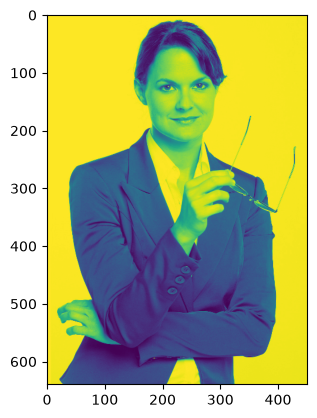

In [20]:
def get_lab_channels_and_gm(img_lab : np.ndarray):

    L, a, b = cv2.split(img_lab)

    sobelx = cv2.Sobel(L, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(L, cv2.CV_64F, 0, 1, ksize=3)

    sobelx = np.square(sobelx) 
    sobely = np.square(sobely)

    # gradient magnitude
    gradient_magnitude = np.sqrt(sobelx + sobely)

    return L, a, b, gradient_magnitude

L, a, b, gradient_magnitude = get_lab_channels_and_gm(img_lab)

plt.imshow(L)

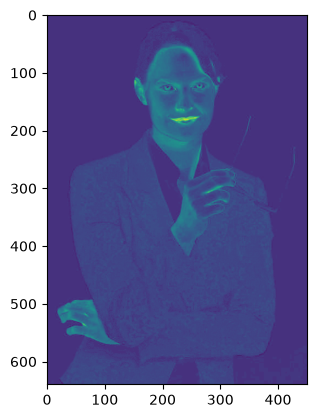

In [21]:
plt.imshow(a)

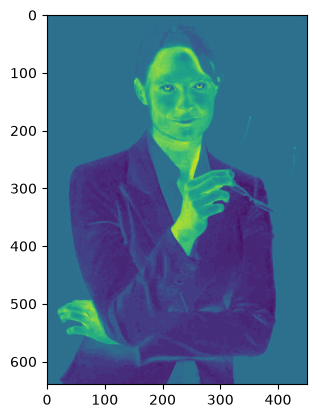

In [22]:
plt.imshow(b)

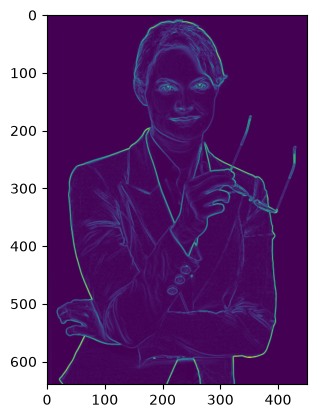

In [23]:
plt.imshow(gradient_magnitude)